In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética de los gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [43]:
# URLs de los archivos CSV
urls = {
    "Tienda 1": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv",
    "Tienda 2": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv",
    "Tienda 3": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv",
    "Tienda 4": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"
}

# Leer los CSV en un diccionario de DataFrames
tiendas = {nombre: pd.read_csv(url) for nombre, url in urls.items()}

# Mostrar las primeras filas de la Tienda 1 como ejemplo
tiendas["Tienda 1"].head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [44]:
# Función para calcular ingresos totales de cada tienda
def calcular_ingresos(df):
    return df["Precio"].sum()

ingresos = {nombre: calcular_ingresos(df) for nombre, df in tiendas.items()}

# Convertir a DataFrame para análisis y gráficos
df_ingresos = pd.DataFrame(list(ingresos.items()), columns=["Tienda", "Ingresos"])
df_ingresos

,Tienda,Ingresos
0,Tienda 1,1.150880e+09
1,Tienda 2,1.116344e+09
2,Tienda 3,1.098020e+09
3,Tienda 4,1.038376e+09


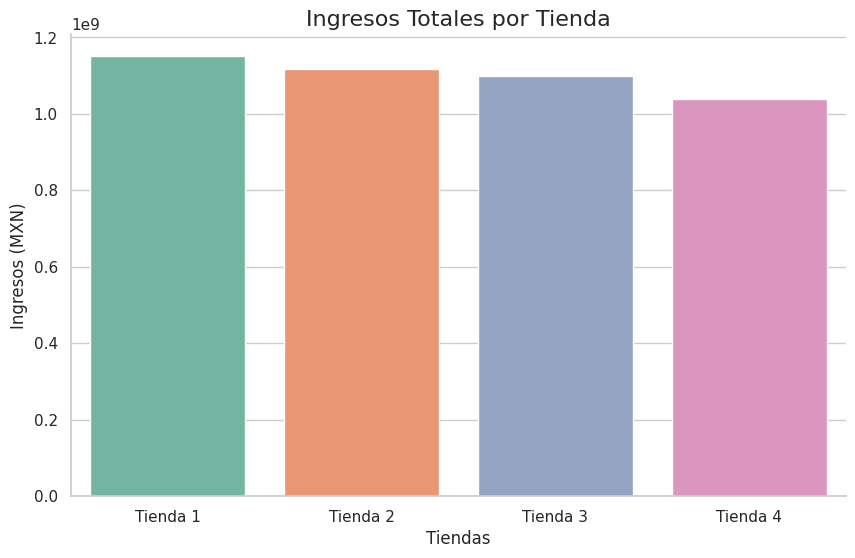

In [50]:
sns.barplot(data=df_ingresos, x="Tienda", y="Ingresos", hue="Tienda", dodge=False, palette="Set2", legend=False)
plt.title("Ingresos Totales por Tienda", fontsize=16)
plt.ylabel("Ingresos (MXN)")
plt.xlabel("Tiendas")
plt.show()

In [46]:
# Función para calcular ventas por categoría
def ventas_por_categoria(df):
    return df.groupby("Categoría del Producto")["Precio"].sum().sort_values(ascending=False)

# Crear un diccionario con las ventas por categoría
ventas_categoria = {nombre: ventas_por_categoria(df) for nombre, df in tiendas.items()}

# Mostrar ventas por categoría de la Tienda 1 como ejemplo
ventas_categoria["Tienda 1"]

,Precio
Categoría del Producto,
Electrónicos,429493500.0
Electrodomésticos,363685200.0
Muebles,187633700.0
Instrumentos musicales,91299000.0
Deportes y diversión,39290000.0
Juguetes,17995700.0
Artículos para el hogar,12698400.0
Libros,8784900.0
